In [30]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [31]:
df = pd.read_csv('data\project1_df.csv')

<>:1: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:1: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
C:\Users\Daryna\AppData\Local\Temp\ipykernel_16724\2209859016.py:1: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  df = pd.read_csv('data\project1_df.csv')


In [32]:
df.columns

Index(['CID', 'TID', 'Gender', 'Age Group', 'Purchase Date',
       'Product Category', 'Discount Availed', 'Discount Name',
       'Discount Amount (INR)', 'Gross Amount', 'Net Amount',
       'Purchase Method', 'Location'],
      dtype='object')

In [33]:
X = pd.DataFrame(df["Age Group"])
y = df["Gross Amount"]

In [34]:
df["Age Group"].unique()

array(['25-45', '60 and above', '18-25', '45-60', 'under 18'],
      dtype=object)

In [35]:
ordinal_encoder = OrdinalEncoder(categories=[["under 18","18-25","25-45","45-60","60 and above"]])
X_encoded = ordinal_encoder.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.25, random_state=42
)


In [36]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MAE: 1440.0554272136444
R2: -8.240996149555535e-05


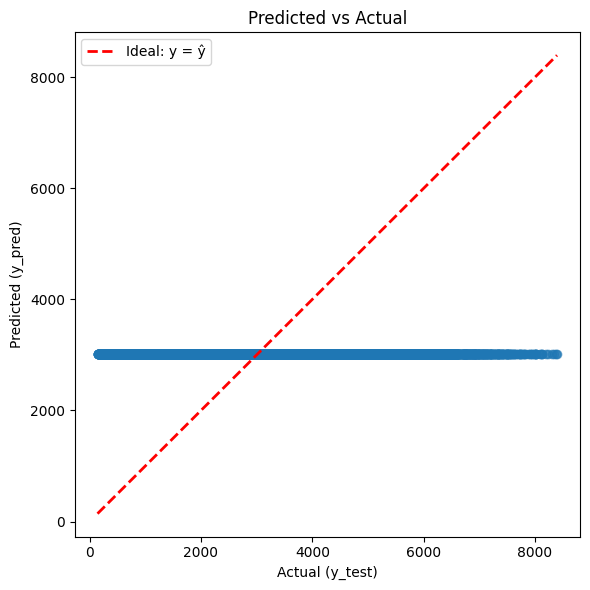

In [37]:
# 1) Predicted vs Actual
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
minv = min(np.min(y_test), np.min(y_pred))
maxv = max(np.max(y_test), np.max(y_pred))
plt.plot([minv, maxv], [minv, maxv], "r--", lw=2, label="Ideal: y = ŷ")
plt.xlabel("Actual (y_test)")
plt.ylabel("Predicted (y_pred)")
plt.title("Predicted vs Actual")
plt.legend()
plt.tight_layout()
plt.show()
